# EEG Raw 1D CNN Training Notebook — 60/20/20 Split + Grouped Cross-Validation

This notebook trains a 1D CNN on raw EEG `.npz` windows.

Included changes:

- filters all windows to one consistent channel count
- uses a 60/20/20 train/validation/test split
- guarantees seizure samples appear in train/val/test
- normalizes each EEG window per channel
- uses weighted sampling for imbalance
- avoids using both weighted sampling and `pos_weight`
- tunes threshold on validation data
- evaluates on test data
- adds grouped cross-validation for a more reliable performance estimate

## 1. Imports

In [83]:
import subprocess
import sys
import os

from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score, precision_recall_curve
)

## 2. Configuration

In [84]:
MANIFEST_PATH = Path("artifacts/static/raw_windows_manifest.csv")
MODEL_PATH = Path("artifacts/static/eeg_1d_cnn.pt")

BATCH_SIZE = 32
EPOCHS = 20
CV_EPOCHS = 8
LR = 1e-3
RANDOM_STATE = 42

# 10 seconds at 256 Hz
TARGET_SAMPLES = 2560

# Cross-validation settings
N_SPLITS = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 3. Export raw windows

Runs `scripts/export_raw_windows.py` to slice all EDF files into labeled `.npz` windows and write `artifacts/static/raw_windows_manifest.csv`. Skip this cell if the manifest already exists.

In [ ]:
repo_root = Path.cwd()
output_root = repo_root / "artifacts" / "static"
output_root.mkdir(parents=True, exist_ok=True)

cmd = [sys.executable, str(repo_root / "scripts" / "export_raw_windows.py")]

print("Running command:")
print(" ".join(cmd))

env = os.environ.copy()
env["PYTHONPATH"] = str(repo_root / "src")

result = subprocess.run(
    cmd,
    cwd=repo_root,
    env=env,
    text=True,
    capture_output=True,
)

print("STDOUT:\n")
print(result.stdout)

if result.stderr:
    print("STDERR:\n")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"export_raw_windows.py failed with exit code {result.returncode}")

print("\nExport completed.")
print("Files in output_root:")
for p in sorted(output_root.iterdir()):
    print(" -", p.name)


## 4. Load manifest

In [85]:
df = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", df.shape)
display(df.head())

print("\nOriginal class counts:")
print(df["target"].value_counts())

Manifest shape: (20060, 16)


,file_path,source_edf,source_file_name,dataset,subject_id,session_id,epoch_index,window_start_sec,window_end_sec,duration_sec,label,target,n_channels,n_samples,sfreq,channel_order
0,artifacts/static/raw_windows/chbmit_chb01_chb0...,data/chbmit/chb01/chb01_01.edf,chb01_01.edf,chbmit,chb01,chb01_01,10,100.0,110.0,10,interictal,0,23,2560,256,FP1-F7|F7-T7|T7-P7|P7-O1|FP1-F3|F3-C3|C3-P3|P3...
1,artifacts/static/raw_windows/chbmit_chb01_chb0...,data/chbmit/chb01/chb01_01.edf,chb01_01.edf,chbmit,chb01,chb01_01,46,460.0,470.0,10,interictal,0,23,2560,256,FP1-F7|F7-T7|T7-P7|P7-O1|FP1-F3|F3-C3|C3-P3|P3...
2,artifacts/static/raw_windows/chbmit_chb01_chb0...,data/chbmit/chb01/chb01_01.edf,chb01_01.edf,chbmit,chb01,chb01_01,51,510.0,520.0,10,interictal,0,23,2560,256,FP1-F7|F7-T7|T7-P7|P7-O1|FP1-F3|F3-C3|C3-P3|P3...
3,artifacts/static/raw_windows/chbmit_chb01_chb0...,data/chbmit/chb01/chb01_01.edf,chb01_01.edf,chbmit,chb01,chb01_01,75,750.0,760.0,10,interictal,0,23,2560,256,FP1-F7|F7-T7|T7-P7|P7-O1|FP1-F3|F3-C3|C3-P3|P3...
4,artifacts/static/raw_windows/chbmit_chb01_chb0...,data/chbmit/chb01/chb01_01.edf,chb01_01.edf,chbmit,chb01,chb01_01,128,1280.0,1290.0,10,interictal,0,23,2560,256,FP1-F7|F7-T7|T7-P7|P7-O1|FP1-F3|F3-C3|C3-P3|P3...



Original class counts:
target
0    19794
1      266
Name: count, dtype: int64


## 5. Clean manifest

In [86]:
df["file_exists"] = df["file_path"].apply(lambda p: Path(p).exists())
print("Missing files:", (~df["file_exists"]).sum())

df = df[df["file_exists"]].copy()
df = df[df["target"].isin([0, 1])].copy()
df["target"] = df["target"].astype(int)

print("Cleaned shape before channel filtering:", df.shape)
print(df["target"].value_counts())

Missing files: 0
Cleaned shape before channel filtering: (20060, 17)
target
0    19794
1      266
Name: count, dtype: int64


## 6. Filter to one consistent channel count

In [87]:
def get_npz_shape(path):
    loaded = np.load(path, allow_pickle=True)
    return loaded["window"].shape

df["window_shape"] = df["file_path"].apply(get_npz_shape)
df["n_channels_actual"] = df["window_shape"].apply(lambda s: min(s[0], s[1]))
df["n_samples_actual"] = df["window_shape"].apply(lambda s: max(s[0], s[1]))

print("Window shapes:")
print(df["window_shape"].value_counts())

print("\nChannel counts:")
print(df["n_channels_actual"].value_counts())

TARGET_CHANNELS = df["n_channels_actual"].value_counts().idxmax()

df = df[
    (df["n_channels_actual"] == TARGET_CHANNELS) &
    (df["n_samples_actual"] == TARGET_SAMPLES)
].copy()

print("\nUsing channel count:", TARGET_CHANNELS)
print("Filtered dataset shape:", df.shape)
print("Filtered class counts:")
print(df["target"].value_counts())

if "dataset" in df.columns:
    print("\nCounts by dataset and target:")
    print(df.groupby(["dataset", "target"]).size())

Window shapes:
window_shape
(23, 2560)    10025
(28, 2560)     4768
(24, 2560)     3607
(38, 2560)      681
(22, 2560)      480
(29, 2560)      243
(35, 2560)      224
(25, 2560)       19
(31, 2560)       13
Name: count, dtype: int64

Channel counts:
n_channels_actual
23    10025
28     4768
24     3607
38      681
22      480
29      243
35      224
25       19
31       13
Name: count, dtype: int64

Using channel count: 23
Filtered dataset shape: (10025, 20)
Filtered class counts:
target
0    9777
1     248
Name: count, dtype: int64

Counts by dataset and target:
dataset  target
chbmit   0         9777
         1          248
dtype: int64


## 7. Inspect one filtered sample

In [88]:
sample_path = Path(df.iloc[0]["file_path"])
sample = np.load(sample_path, allow_pickle=True)

window = sample["window"].astype(np.float32)

if window.shape[0] > window.shape[1]:
    window = window.T

window_norm = window - window.mean(axis=1, keepdims=True)
window_norm = window_norm / (window_norm.std(axis=1, keepdims=True) + 1e-6)

print("Sample file:", sample_path)
print("Keys:", sample.files)
print("Raw shape:", window.shape)
print("Raw mean/std:", window.mean(), window.std())
print("Norm mean/std:", window_norm.mean(), window_norm.std())

Sample file: artifacts/static/raw_windows/chbmit_chb01_chb01_01_epoch_000010.npz
Keys: ['window', 'fs', 'channel_order', 'dataset', 'subject_id', 'session_id', 'window_start_sec', 'window_end_sec', 'target', 'label']
Raw shape: (23, 2560)
Raw mean/std: 9.439527e-08 2.084016e-05
Norm mean/std: -5.830889e-10 0.95128846


## 8. Choose grouped split column

In [89]:
# For development, session_id is usually more stable.
# For final patient-generalization reporting, subject_id is stricter.
if "session_id" in df.columns:
    group_col = "session_id"
elif "subject_id" in df.columns:
    group_col = "subject_id"
else:
    raise ValueError("Need either session_id or subject_id in the manifest.")

print("Using group column:", group_col)
print("Number of groups:", df[group_col].nunique())

Using group column: session_id
Number of groups: 276


## 9. Create a 60/20/20 split with seizure samples in each set

In [90]:
def make_60_20_20_group_split_with_positives(
    df,
    group_col,
    random_state=42,
    max_tries=300,
    min_train_pos=1,
    min_val_pos=1,
    min_test_pos=1
):
    for seed in range(random_state, random_state + max_tries):
        # First split: 60% train, 40% temp
        splitter1 = GroupShuffleSplit(test_size=0.40, random_state=seed)

        train_idx, temp_idx = next(
            splitter1.split(df, df["target"], groups=df[group_col])
        )

        train_df = df.iloc[train_idx].reset_index(drop=True)
        temp_df = df.iloc[temp_idx].reset_index(drop=True)

        # Second split: temp becomes 20% val and 20% test
        splitter2 = GroupShuffleSplit(test_size=0.50, random_state=seed)

        val_idx, test_idx = next(
            splitter2.split(temp_df, temp_df["target"], groups=temp_df[group_col])
        )

        val_df = temp_df.iloc[val_idx].reset_index(drop=True)
        test_df = temp_df.iloc[test_idx].reset_index(drop=True)

        if (
            train_df["target"].sum() >= min_train_pos and
            val_df["target"].sum() >= min_val_pos and
            test_df["target"].sum() >= min_test_pos
        ):
            print("Successful split seed:", seed)
            return train_df, val_df, test_df

    raise ValueError("Could not create a 60/20/20 split with enough seizure samples.")

train_df, val_df, test_df = make_60_20_20_group_split_with_positives(
    df,
    group_col=group_col,
    random_state=RANDOM_STATE,
    min_train_pos=1,
    min_val_pos=1,
    min_test_pos=1
)

print("Train:", train_df.shape, train_df["target"].value_counts().to_dict())
print("Val:", val_df.shape, val_df["target"].value_counts().to_dict())
print("Test:", test_df.shape, test_df["target"].value_counts().to_dict())

print("\nApproximate split percentages:")
total = len(df)
print("Train:", len(train_df) / total)
print("Val:", len(val_df) / total)
print("Test:", len(test_df) / total)

Successful split seed: 42
Train: (6023, 20) {0: 5904, 1: 119}
Val: (2081, 20) {0: 2015, 1: 66}
Test: (1921, 20) {0: 1858, 1: 63}

Approximate split percentages:
Train: 0.6007980049875312
Val: 0.20758104738154615
Test: 0.1916209476309227


## 10. PyTorch Dataset with per-channel normalization

In [91]:
class EEGRawWindowDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        loaded = np.load(row["file_path"], allow_pickle=True)
        x = loaded["window"].astype(np.float32)

        # Ensure channels x samples
        if x.shape[0] > x.shape[1]:
            x = x.T

        # Normalize each EEG channel independently
        x = x - x.mean(axis=1, keepdims=True)
        x = x / (x.std(axis=1, keepdims=True) + 1e-6)

        y = np.float32(row["target"])

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

## 11. Helper functions for loaders, model, training, prediction, and threshold tuning

In [92]:
def make_loaders(train_df, val_df=None, test_df=None, batch_size=32):
    train_targets = train_df["target"].values
    class_counts = np.bincount(train_targets, minlength=2)

    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[train_targets]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_dataset = EEGRawWindowDataset(train_df)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)

    loaders = {"train": train_loader}

    if val_df is not None:
        val_dataset = EEGRawWindowDataset(val_df)
        loaders["val"] = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    if test_df is not None:
        test_dataset = EEGRawWindowDataset(test_df)
        loaders["test"] = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return loaders


class EEG1DCNN(nn.Module):
    def __init__(self, n_channels):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=9, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def get_probs_and_labels(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    return np.array(all_probs), np.array(all_labels).astype(int)


def tune_threshold(probs, labels, target_recall=0.90):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = None
    best_precision = -1
    best_recall = 0

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)

        rec = recall_score(labels, preds, zero_division=0)
        prec = precision_score(labels, preds, zero_division=0)

        if rec >= target_recall:
            if prec > best_precision:
                best_precision = prec
                best_threshold = threshold
                best_recall = rec

    # Fallback if no threshold meets recall target
    if best_threshold is None:
        print("No threshold met target recall. Falling back to best F1.")

        best_f1 = -1
        for threshold in thresholds:
            preds = (probs >= threshold).astype(int)
            score = f1_score(labels, preds, zero_division=0)

            if score > best_f1:
                best_f1 = score
                best_threshold = threshold
                best_recall = recall_score(labels, preds, zero_division=0)
                best_precision = precision_score(labels, preds, zero_division=0)

    return best_threshold, best_precision, best_recall

def evaluate_predictions(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)

    metrics = {
        "pr_auc": average_precision_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0,
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds)
    }

    return metrics, preds

## 12. Train main 60/20/20 model

In [93]:
loaders = make_loaders(train_df, val_df=val_df, test_df=test_df, batch_size=BATCH_SIZE)

example_x, example_y = EEGRawWindowDataset(train_df)[0]
n_channels = example_x.shape[0]

model = EEG1DCNN(n_channels=n_channels).to(DEVICE)

# Use weighted sampler OR pos_weight, not both.
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_val_ap = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, DEVICE)

    val_probs, val_labels = get_probs_and_labels(model, loaders["val"], DEVICE)

    if len(np.unique(val_labels)) < 2:
        val_ap = 0.0
    else:
        val_ap = average_precision_score(val_labels, val_probs)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val PR-AUC: {val_ap:.4f}")

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

model = model.to(DEVICE)

print("Best validation PR-AUC:", best_val_ap)

Epoch 01/20 | Train Loss: 0.1217 | Val PR-AUC: 0.7389
Epoch 02/20 | Train Loss: 0.0261 | Val PR-AUC: 0.6770
Epoch 03/20 | Train Loss: 0.0200 | Val PR-AUC: 0.7244
Epoch 04/20 | Train Loss: 0.0110 | Val PR-AUC: 0.7536
Epoch 05/20 | Train Loss: 0.0099 | Val PR-AUC: 0.7399
Epoch 06/20 | Train Loss: 0.0043 | Val PR-AUC: 0.6457
Epoch 07/20 | Train Loss: 0.0510 | Val PR-AUC: 0.7698
Epoch 08/20 | Train Loss: 0.0143 | Val PR-AUC: 0.7064
Epoch 09/20 | Train Loss: 0.0137 | Val PR-AUC: 0.7351
Epoch 10/20 | Train Loss: 0.0044 | Val PR-AUC: 0.7775
Epoch 11/20 | Train Loss: 0.0052 | Val PR-AUC: 0.7290
Epoch 12/20 | Train Loss: 0.0050 | Val PR-AUC: 0.7674
Epoch 13/20 | Train Loss: 0.0061 | Val PR-AUC: 0.7543
Epoch 14/20 | Train Loss: 0.0245 | Val PR-AUC: 0.7281
Epoch 15/20 | Train Loss: 0.0043 | Val PR-AUC: 0.7274
Epoch 16/20 | Train Loss: 0.0021 | Val PR-AUC: 0.7566
Epoch 17/20 | Train Loss: 0.0012 | Val PR-AUC: 0.7551
Epoch 18/20 | Train Loss: 0.0011 | Val PR-AUC: 0.7708
Epoch 19/20 | Train Loss: 0.

## 13. Tune threshold on validation set

In [94]:
val_probs, val_labels = get_probs_and_labels(model, loaders["val"], DEVICE)
best_threshold, best_val_precision, best_val_recall = tune_threshold(
    val_probs,
    val_labels,
    target_recall=0.90
)

print("Chosen threshold:", best_threshold)
print("Validation precision:", best_val_precision)
print("Validation recall:", best_val_recall)

No threshold met target recall. Falling back to best F1.
Chosen threshold: 0.9500000000000001
Validation precision: 0.9777777777777777
Validation recall: 0.6666666666666666


## 14. Evaluate main model on the 20% test set

In [95]:
test_probs, test_labels = get_probs_and_labels(model, loaders["test"], DEVICE)

test_metrics, test_preds = evaluate_predictions(test_probs, test_labels, best_threshold)

print("Test PR-AUC:", test_metrics["pr_auc"])
print("Test Precision:", test_metrics["precision"])
print("Test Recall:", test_metrics["recall"])
print("Test F1:", test_metrics["f1"])

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["non_seizure", "seizure"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(test_metrics["confusion_matrix"])

Test PR-AUC: 0.7787650715325127
Test Precision: 0.8431372549019608
Test Recall: 0.6825396825396826
Test F1: 0.7543859649122807

Classification Report:
              precision    recall  f1-score   support

 non_seizure       0.99      1.00      0.99      1858
     seizure       0.84      0.68      0.75        63

    accuracy                           0.99      1921
   macro avg       0.92      0.84      0.87      1921
weighted avg       0.98      0.99      0.98      1921


Confusion Matrix:
[[1850    8]
 [  20   43]]


## 15. Save main model

In [96]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "n_channels": n_channels,
    "target_channels": int(TARGET_CHANNELS),
    "target_samples": int(TARGET_SAMPLES),
    "best_threshold": float(best_threshold),
    "best_val_pr_auc": float(best_val_ap),
    "best_val_precision": float(best_val_precision),
    "best_val_recall": float(best_val_recall),
}, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: artifacts/static/eeg_1d_cnn.pt


## 16. Inspect test predictions

In [97]:
results_df = test_df.copy()
results_df["prob_seizure"] = test_probs
results_df["pred"] = test_preds

display(results_df[[
    "dataset",
    "subject_id",
    "session_id",
    "window_start_sec",
    "window_end_sec",
    "target",
    "prob_seizure",
    "pred"
]].head(20))

display(results_df.sort_values("prob_seizure", ascending=False)[[
    "dataset",
    "subject_id",
    "session_id",
    "window_start_sec",
    "window_end_sec",
    "target",
    "prob_seizure",
    "pred"
]].head(20))

,dataset,subject_id,session_id,window_start_sec,window_end_sec,target,prob_seizure,pred
0,chbmit,chb01,chb01_03,260.0,270.0,0,1.466213e-04,0
1,chbmit,chb01,chb01_03,320.0,330.0,0,1.334915e-02,0
2,chbmit,chb01,chb01_03,340.0,350.0,0,1.019969e-03,0
3,chbmit,chb01,chb01_03,430.0,440.0,0,1.688216e-03,0
4,chbmit,chb01,chb01_03,490.0,500.0,0,2.798270e-04,0
5,chbmit,chb01,chb01_03,950.0,960.0,0,3.710715e-01,0
6,chbmit,chb01,chb01_03,1030.0,1040.0,0,7.016894e-06,0
7,chbmit,chb01,chb01_03,1180.0,1190.0,0,4.803013e-05,0
8,chbmit,chb01,chb01_03,1260.0,1270.0,0,1.755211e-01,0
9,chbmit,chb01,chb01_03,1590.0,1600.0,0,9.956249e-04,0


,dataset,subject_id,session_id,window_start_sec,window_end_sec,target,prob_seizure,pred
1854,chbmit,chb24,chb24_07,40.0,50.0,1,1.0,1
1902,chbmit,chb24,chb24_18,450.0,460.0,0,1.0,1
244,chbmit,chb01,chb01_26,1910.0,1920.0,1,1.0,1
243,chbmit,chb01,chb01_26,1900.0,1910.0,1,1.0,1
591,chbmit,chb03,chb03_02,770.0,780.0,1,1.0,1
592,chbmit,chb03,chb03_02,780.0,790.0,1,1.0,1
247,chbmit,chb01,chb01_26,1940.0,1950.0,1,1.0,1
248,chbmit,chb01,chb01_26,1950.0,1960.0,1,1.0,1
245,chbmit,chb01,chb01_26,1920.0,1930.0,1,1.0,1
246,chbmit,chb01,chb01_26,1930.0,1940.0,1,1.0,1


## 17. Grouped Cross-Validation

This section trains the CNN multiple times using grouped folds.

Why this matters:

- one split can be lucky or unlucky
- cross-validation gives a more reliable estimate
- grouping prevents windows from the same session from leaking across train/validation

This is more expensive because it trains the CNN once per fold.


===== Fold 1/3 =====
Train counts: {0: 6520, 1: 162}
Val counts: {0: 3257, 1: 86}
Fold 1 Epoch 01/8 | Loss: 0.1298 | Val PR-AUC: 0.7153
Fold 1 Epoch 02/8 | Loss: 0.0290 | Val PR-AUC: 0.7347
Fold 1 Epoch 03/8 | Loss: 0.0217 | Val PR-AUC: 0.7280
Fold 1 Epoch 04/8 | Loss: 0.0222 | Val PR-AUC: 0.7644
Fold 1 Epoch 05/8 | Loss: 0.0173 | Val PR-AUC: 0.7253
Fold 1 Epoch 06/8 | Loss: 0.0136 | Val PR-AUC: 0.7472
Fold 1 Epoch 07/8 | Loss: 0.0066 | Val PR-AUC: 0.7151
Fold 1 Epoch 08/8 | Loss: 0.0181 | Val PR-AUC: 0.7481


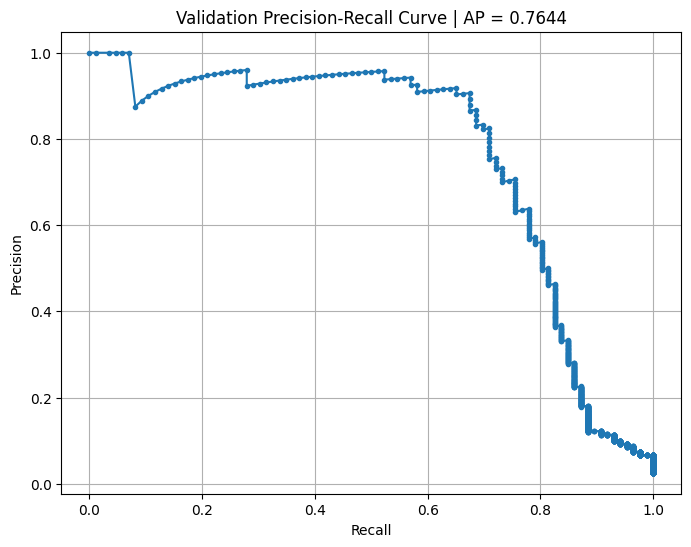

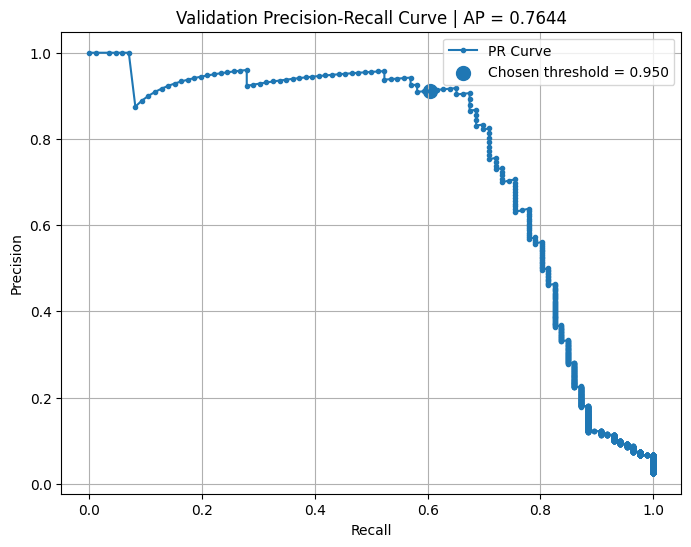

Chosen threshold: 0.9500000000000001
Precision at threshold: 0.9122807017543859
Recall at threshold: 0.6046511627906976
Fold best threshold: 0.12
Fold PR-AUC: 0.7644214802134881
Fold Precision: 0.552
Fold Recall: 0.8023255813953488
Fold F1: 0.6540284360189573
Fold Confusion Matrix:
[[3201   56]
 [  17   69]]

===== Fold 2/3 =====
Train counts: {0: 6500, 1: 182}
Val counts: {0: 3277, 1: 66}
Fold 2 Epoch 01/8 | Loss: 0.1669 | Val PR-AUC: 0.7353
Fold 2 Epoch 02/8 | Loss: 0.0532 | Val PR-AUC: 0.8685
Fold 2 Epoch 03/8 | Loss: 0.0304 | Val PR-AUC: 0.7960
Fold 2 Epoch 04/8 | Loss: 0.0223 | Val PR-AUC: 0.8366
Fold 2 Epoch 05/8 | Loss: 0.0352 | Val PR-AUC: 0.8578
Fold 2 Epoch 06/8 | Loss: 0.0134 | Val PR-AUC: 0.8439
Fold 2 Epoch 07/8 | Loss: 0.0126 | Val PR-AUC: 0.7939
Fold 2 Epoch 08/8 | Loss: 0.0166 | Val PR-AUC: 0.8221


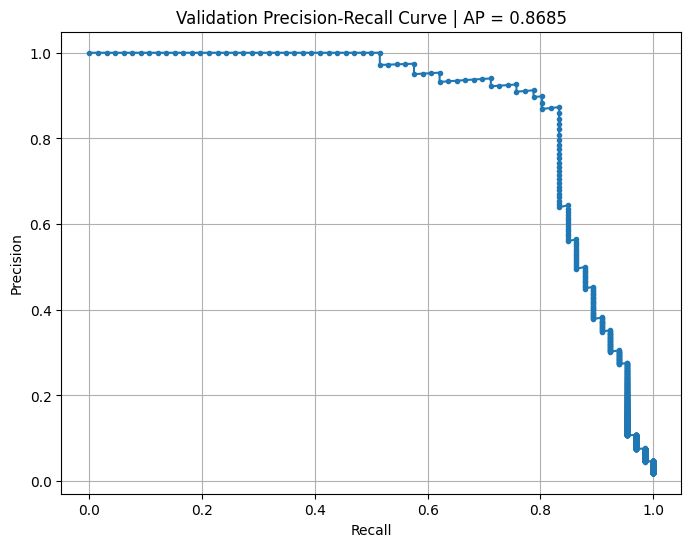

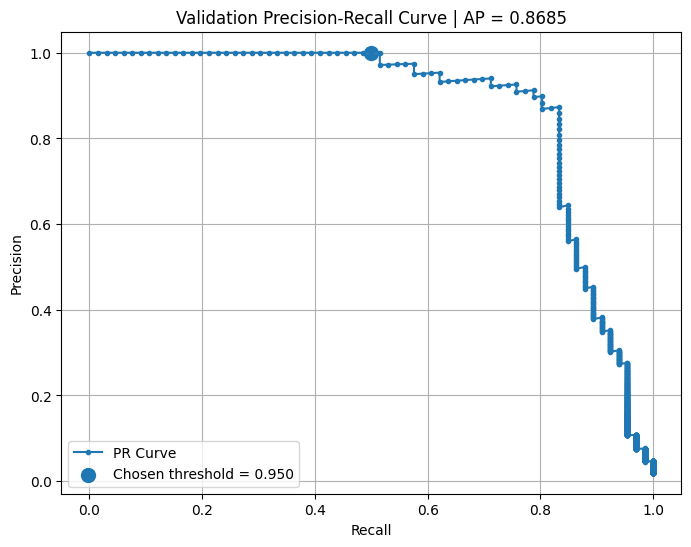

Chosen threshold: 0.9500000000000001
Precision at threshold: 1.0
Recall at threshold: 0.5
Fold best threshold: 0.33
Fold PR-AUC: 0.8684734110296952
Fold Precision: 0.8983050847457628
Fold Recall: 0.803030303030303
Fold F1: 0.848
Fold Confusion Matrix:
[[3271    6]
 [  13   53]]

===== Fold 3/3 =====
Train counts: {0: 6534, 1: 152}
Val counts: {0: 3243, 1: 96}
Fold 3 Epoch 01/8 | Loss: 0.1383 | Val PR-AUC: 0.8551
Fold 3 Epoch 02/8 | Loss: 0.0528 | Val PR-AUC: 0.8022
Fold 3 Epoch 03/8 | Loss: 0.0279 | Val PR-AUC: 0.8593
Fold 3 Epoch 04/8 | Loss: 0.0205 | Val PR-AUC: 0.8402
Fold 3 Epoch 05/8 | Loss: 0.0111 | Val PR-AUC: 0.8513
Fold 3 Epoch 06/8 | Loss: 0.0225 | Val PR-AUC: 0.7728
Fold 3 Epoch 07/8 | Loss: 0.0192 | Val PR-AUC: 0.8667
Fold 3 Epoch 08/8 | Loss: 0.0138 | Val PR-AUC: 0.8050


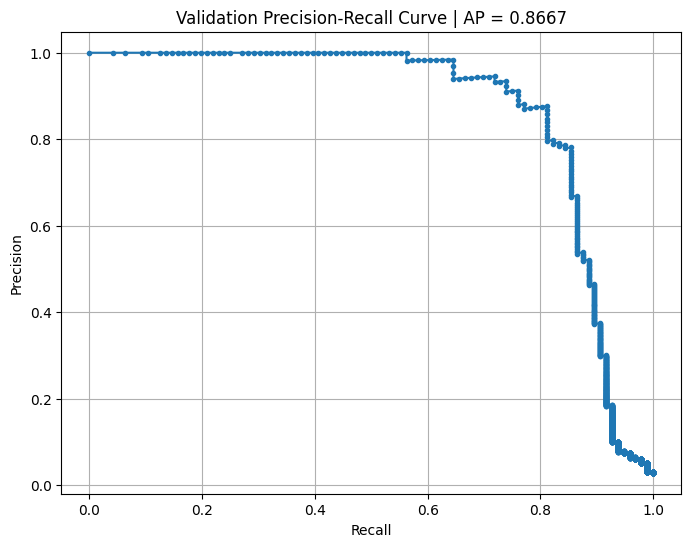

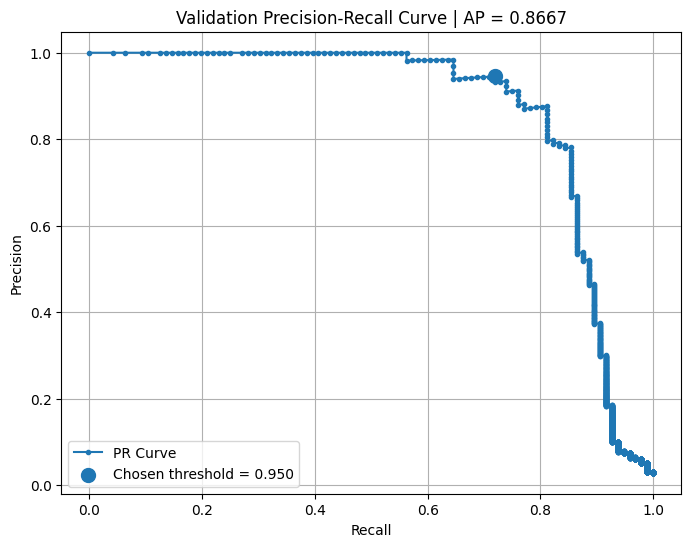

Chosen threshold: 0.9500000000000001
Precision at threshold: 0.9452054794520548
Recall at threshold: 0.71875
Fold best threshold: 0.5
Fold PR-AUC: 0.8667453117359687
Fold Precision: 0.8764044943820225
Fold Recall: 0.8125
Fold F1: 0.8432432432432433
Fold Confusion Matrix:
[[3232   11]
 [  18   78]]


,fold,train_size,val_size,train_pos,val_pos,threshold,pr_auc,precision,recall,f1
0,1,6682,3343,162,86,0.12,0.764421,0.552000,0.802326,0.654028
1,2,6682,3343,182,66,0.33,0.868473,0.898305,0.803030,0.848000
2,3,6686,3339,152,96,0.50,0.866745,0.876404,0.812500,0.843243


,pr_auc,precision,recall,f1
mean,0.833213,0.775570,0.805952,0.781757
std,0.059582,0.193927,0.005682,0.110642
min,0.764421,0.552000,0.802326,0.654028
max,0.868473,0.898305,0.812500,0.848000



Cross-Validation Summary
Mean PR-AUC:    0.8332 ± 0.0596
Mean Precision: 0.7756 ± 0.1939
Mean Recall:    0.8060 ± 0.0057
Mean F1:        0.7818 ± 0.1106

Best Fold by F1
fold             2.000000
train_size    6682.000000
val_size      3343.000000
train_pos      182.000000
val_pos         66.000000
threshold        0.330000
pr_auc           0.868473
precision        0.898305
recall           0.803030
f1               0.848000
Name: 1, dtype: float64

Worst Fold by F1
fold             1.000000
train_size    6682.000000
val_size      3343.000000
train_pos      162.000000
val_pos         86.000000
threshold        0.120000
pr_auc           0.764421
precision        0.552000
recall           0.802326
f1               0.654028
Name: 0, dtype: float64


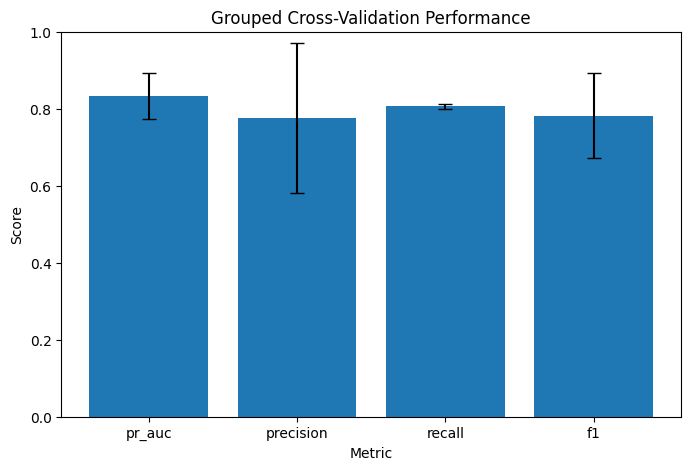

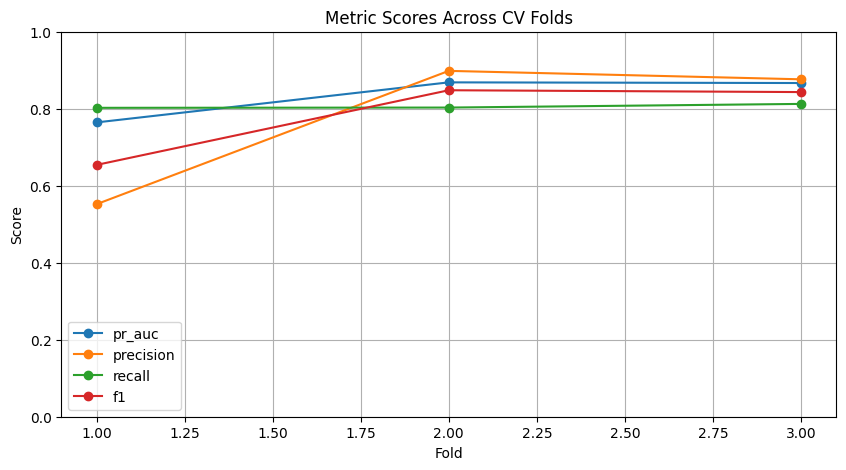

In [ ]:
import matplotlib.pyplot as plt
def run_grouped_cross_validation(df, group_col, n_splits=3, epochs=8):
    gkf = GroupKFold(n_splits=n_splits)

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(df, df["target"], groups=df[group_col]),
        start=1
    ):
        fold_train_df = df.iloc[train_idx].reset_index(drop=True)
        fold_val_df = df.iloc[val_idx].reset_index(drop=True)

        train_pos = int(fold_train_df["target"].sum())
        val_pos = int(fold_val_df["target"].sum())

        print(f"\n===== Fold {fold}/{n_splits} =====")
        print("Train counts:", fold_train_df["target"].value_counts().to_dict())
        print("Val counts:", fold_val_df["target"].value_counts().to_dict())

        if train_pos == 0 or val_pos == 0:
            print("Skipping fold because it is missing seizure samples.")
            continue

        fold_loaders = make_loaders(
            fold_train_df,
            val_df=fold_val_df,
            batch_size=BATCH_SIZE
        )

        example_x, _ = EEGRawWindowDataset(fold_train_df)[0]
        fold_model = EEG1DCNN(n_channels=example_x.shape[0]).to(DEVICE)

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-4)

        best_fold_ap = -1
        best_fold_state = None

        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(
                fold_model,
                fold_loaders["train"],
                criterion,
                optimizer,
                DEVICE
            )

            val_probs, val_labels = get_probs_and_labels(
                fold_model,
                fold_loaders["val"],
                DEVICE
            )

            val_ap = average_precision_score(val_labels, val_probs)

            print(
                f"Fold {fold} Epoch {epoch:02d}/{epochs} | "
                f"Loss: {train_loss:.4f} | Val PR-AUC: {val_ap:.4f}"
            )

            if val_ap > best_fold_ap:
                best_fold_ap = val_ap
                best_fold_state = {
                    k: v.cpu().clone()
                    for k, v in fold_model.state_dict().items()
                }

        if best_fold_state is not None:
            fold_model.load_state_dict(best_fold_state)

        fold_model = fold_model.to(DEVICE)

        val_probs, val_labels = get_probs_and_labels(
            fold_model,
            fold_loaders["val"],
            DEVICE
        )


        precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
        ap_score = average_precision_score(val_labels, val_probs)

        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, marker=".")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Validation Precision-Recall Curve | AP = {ap_score:.4f}")
        plt.grid(True)
        plt.show()
        
        fold_threshold, fold_precision, fold_recall = tune_threshold(
            val_probs,
            val_labels,
            target_recall=0.80   
        )
        fold_metrics, fold_preds = evaluate_predictions(
            val_probs,
            val_labels,
            fold_threshold
        )

        print("Fold best threshold:", fold_threshold)
        print("Fold PR-AUC:", fold_metrics["pr_auc"])
        print("Fold Precision:", fold_metrics["precision"])
        print("Fold Recall:", fold_metrics["recall"])
        print("Fold F1:", fold_metrics["f1"])
        print("Fold Confusion Matrix:")
        print(fold_metrics["confusion_matrix"])

        fold_results.append({
            "fold": fold,
            "train_size": len(fold_train_df),
            "val_size": len(fold_val_df),
            "train_pos": train_pos,
            "val_pos": val_pos,
            "threshold": fold_threshold,
            "pr_auc": fold_metrics["pr_auc"],
            "precision": fold_metrics["precision"],
            "recall": fold_metrics["recall"],
            "f1": fold_metrics["f1"]
        })

    return pd.DataFrame(fold_results)


cv_results = run_grouped_cross_validation(
    df,
    group_col=group_col,
    n_splits=N_SPLITS,
    epochs=CV_EPOCHS
)

display(cv_results)

summary = cv_results[["pr_auc", "precision", "recall", "f1"]].agg(
    ["mean", "std", "min", "max"]
)

display(summary)

print("\nCross-Validation Summary")
print("=" * 40)
print(f"Mean PR-AUC:    {cv_results['pr_auc'].mean():.4f} ± {cv_results['pr_auc'].std():.4f}")
print(f"Mean Precision: {cv_results['precision'].mean():.4f} ± {cv_results['precision'].std():.4f}")
print(f"Mean Recall:    {cv_results['recall'].mean():.4f} ± {cv_results['recall'].std():.4f}")
print(f"Mean F1:        {cv_results['f1'].mean():.4f} ± {cv_results['f1'].std():.4f}")

print("\nBest Fold by F1")
best_fold = cv_results.loc[cv_results["f1"].idxmax()]
print(best_fold)

print("\nWorst Fold by F1")
worst_fold = cv_results.loc[cv_results["f1"].idxmin()]
print(worst_fold)


metrics = ["pr_auc", "precision", "recall", "f1"]

means = cv_results[metrics].mean()
stds = cv_results[metrics].std()

plt.figure(figsize=(8, 5))
plt.bar(metrics, means, yerr=stds, capsize=5)
plt.ylim(0, 1)
plt.title("Grouped Cross-Validation Performance")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.show()
plt.figure(figsize=(10, 5))

for metric in metrics:
    plt.plot(cv_results["fold"], cv_results[metric], marker="o", label=metric)

plt.ylim(0, 1)
plt.title("Metric Scores Across CV Folds")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## 18. Notes for final reporting

Use the single 60/20/20 split for model development and saving a final model.

Use grouped cross-validation results to describe how stable the CNN is across different sessions.

For the final report, include:

- train/validation/test class counts
- test confusion matrix
- test seizure precision
- test seizure recall
- test PR-AUC
- grouped CV average PR-AUC, precision, recall, and F1